In [1]:
%cd ..

/home/fzimin/Projects/depth-poset


In [2]:
import numpy as np
import networkx as nx
import pandas as pd


import matplotlib.pyplot as plt

from src.depth import DepthPoset, ShallowPair
from src.transpositions import Transposition

# Data

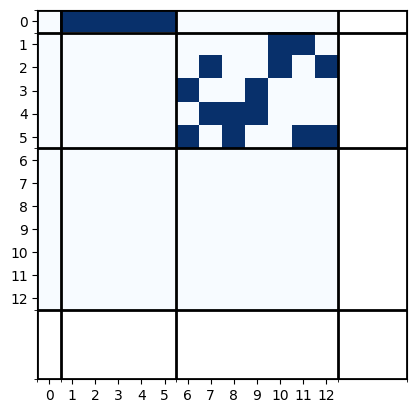

In [3]:
delta_matrix = np.zeros([16, 16], dtype=int)
delta_matrix[0, 1:6] = 1
delta_matrix[1:6, 6:13] = np.array([[1, 1, 0, 0, 0, 0, 0], 
                                    [1, 0, 1, 1, 0, 0, 0], 
                                    [0, 1, 1, 0, 1, 1, 0], 
                                    [0, 0, 0, 1, 1, 0, 1], 
                                    [0, 0, 0, 0, 0, 1, 1]])
delta_matrix[6:13, 13:16] = np.array([[1, 0, 0], 
                                      [1, 0, 0], 
                                      [1, 1, 0], 
                                      [0, 1, 0], 
                                      [0, 1, 1], 
                                      [0, 0, 1], 
                                      [0, 0, 1]])
reorder = np.array([ 0,  1,  2,  5,  4,  3, 11,  9, 10, 12,  6,  7,  8, 14, 13, 15])


delta_matrix = delta_matrix[reorder, :][:, reorder]

delta_matrix = delta_matrix[:13, :][:, :13]


fig, ax = plt.subplots()

ax.imshow(delta_matrix, cmap='Blues')
ax.set_xticks(np.arange(len(delta_matrix)))
ax.set_xticklabels(np.arange(len(delta_matrix)))
ax.set_xticks([-0.5, 0.5, 5.5, 12.5, 15.5], minor=True)

ax.set_yticks(np.arange(len(delta_matrix)))
ax.set_yticklabels(np.arange(len(delta_matrix)))
ax.set_yticks([-0.5, 0.5, 5.5, 12.5, 15.5], minor=True)

ax.grid(which="minor", linewidth=2, alpha=1.0, color='black')

plt.show()

In [4]:
delta_order = np.arange(len(delta_matrix))
delta_order

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [5]:
delta_dims = -np.ones(len(delta_matrix), dtype=int)
delta_dims[1:6] = 0
delta_dims[6:13] = 1
delta_dims[13:16] = 2
delta_dims = delta_dims[:len(delta_matrix)]

delta_dims

array([-1,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1])

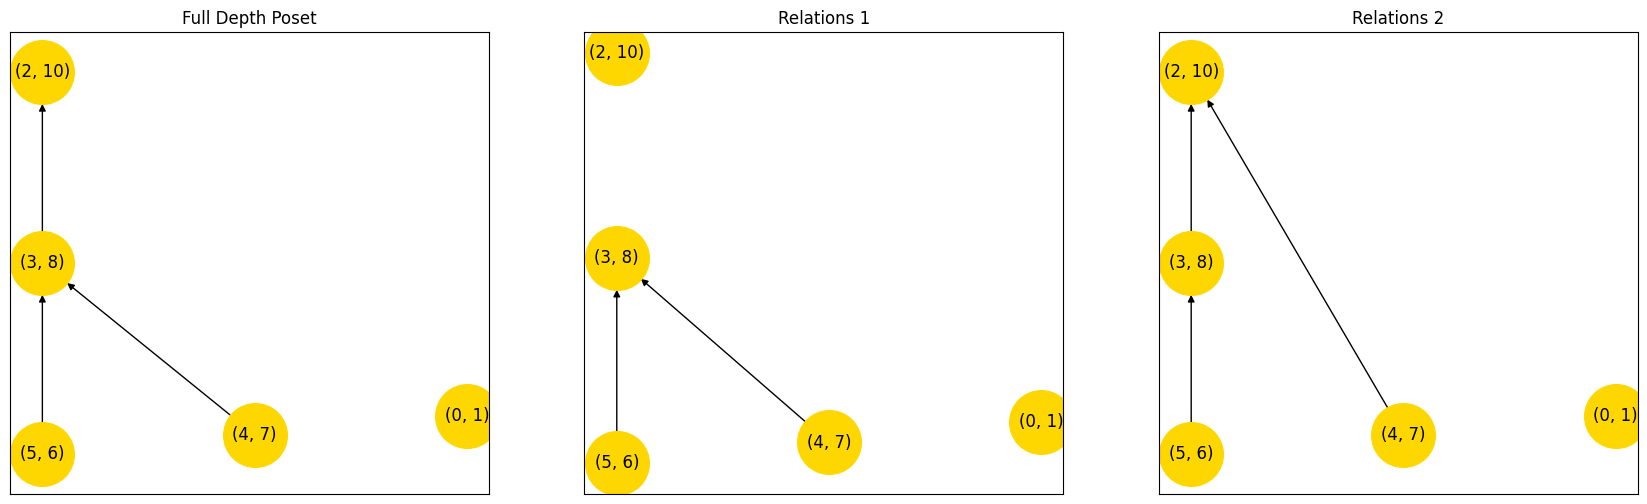

In [6]:
dp_bt = DepthPoset.from_border_matrix(delta_matrix, delta_dims, sources=np.arange(len(delta_matrix)))

pos = dp_bt.hasse_layout(alignment_slope=0.1)
labels = {node: (node.birth_index, node.death_index) for node in dp_bt.nodes}


fig, axs = plt.subplots(1, 3, figsize=(21, 6))

axs[0].set_title('Full Depth Poset')
axs[1].set_title('Relations 1')
axs[2].set_title('Relations 2')
nx.draw_networkx(dp_bt.get_transitive_reduction(), ax=axs[0], pos=pos, labels=labels, node_size=2100, node_color='gold')
nx.draw_networkx(dp_bt.get_column_bottom_to_top_reduction().get_transitive_reduction(), ax=axs[1], pos=pos, labels=labels, node_size=2100, node_color='gold')
nx.draw_networkx(dp_bt.get_row_left_to_right_reduction().get_transitive_reduction(), ax=axs[2], pos=pos, labels=labels, node_size=2100, node_color='gold')

plt.show()

In [7]:
dp_bt.nodes[0].source, dp_bt.nodes[0].dim

((np.int64(5), np.int64(6)), np.int64(0))

# Collect Transpositions

In [8]:
df_transps = pd.DataFrame({'cell0': np.arange(0, len(delta_matrix) - 1), 'cell1': np.arange(1, len(delta_matrix))})

df_transps['transposition'] = df_transps.apply(lambda row: Transposition(delta_matrix, row['cell0'], row['cell1'], 
                                                                         order=delta_order, dims=delta_dims, dp=dp_bt), axis=1)
df_transps['dim'] = df_transps['transposition'].apply(lambda transp: transp.dim)
df_transps['transposition_type'] = df_transps['transposition'].apply(lambda transp: transp.get_transposition_type())
df_transps['switch_type'] = df_transps['transposition'].apply(lambda transp: transp.get_switch_type())
#df_transps['xyab'] = df_transps['transposition'].apply(lambda transp: transp.get_xyab())

#for i, c in enumerate('xyab'):
#    df_transps[c] = df_transps['xyab'].apply(lambda arr: arr[i])
#df_transps = df_transps.drop(columns='xyab')


df_transps['dp_at'] = df_transps['transposition'].apply(lambda transp: transp.next_depth_poset())
df_transps

/home/fzimin/Projects/depth-poset/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:201: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)


,cell0,cell1,transposition,dim,transposition_type,switch_type,dp_at
0,0,1,"<0, 1>",NaN,birth-death,no switch,<src.depth.DepthPoset object at 0x777b0833cda0>
1,1,2,"<1, 2>",0.0,birth-death,switch forward,<src.depth.DepthPoset object at 0x777a97d13bf0>
2,2,3,"<2, 3>",0.0,birth-birth,switch forward,<src.depth.DepthPoset object at 0x777a97cb3050>
3,3,4,"<3, 4>",0.0,birth-birth,no switch,<src.depth.DepthPoset object at 0x777a97d12d20>
4,4,5,"<4, 5>",0.0,birth-birth,no switch,<src.depth.DepthPoset object at 0x777a97d5e8a0>
5,5,6,"<5, 6>",NaN,birth-death,no switch,<src.depth.DepthPoset object at 0x777a97e0b3e0>
6,6,7,"<6, 7>",1.0,death-death,no switch,<src.depth.DepthPoset object at 0x777a97dd08f0>
7,7,8,"<7, 8>",1.0,death-death,switch forward,<src.depth.DepthPoset object at 0x777a97dd11f0>
8,8,9,"<8, 9>",1.0,death-unpaired,undefined,<src.depth.DepthPoset object at 0x777a97e099a0>
9,9,10,"<9, 10>",1.0,death-unpaired,undefined,<src.depth.DepthPoset object at 0x777a97e22390>


In [9]:
df_transps[['transposition_type', 'switch_type']].value_counts().sort_index()

transposition_type  switch_type   
birth-birth         no switch         2
                    switch forward    1
birth-death         no switch         2
                    switch forward    1
death-death         no switch         1
                    switch forward    1
death-unpaired      undefined         3
unpaired-unpaired   undefined         1
Name: count, dtype: int64

In [10]:
transp = df_transps['dp_at'].iloc[2]
transp

## Birth-Birth Transposition

__Lemma 3.3__: Let $f: K\to\mathbb{R}$ be a filter on a Lefscetz complex and $(x, y)$, $(a, b)$ birth-death pairs of matching dimension such that $f(a) < f(x) < f(y) < f(b)$ and $a, x$ are consequtive in the ordering implyed by the filer. Then $a<y$ iff the transposition of $x, a$ is a BB-type switch transposition, and the succesors predecessors determined by Algorithm 1 satisfy:

8. $\text{Succ}_1^\text{at}(a, y) = \text{Succ}_1^\text{bt}(x, y) \oplus \{(x, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$
9. $\text{Succ}_1^\text{at}(x, b) = \text{Succ}_1^\text{bt}(a, b)$
10. $\text{Pred}_1^\text{at}(a, y) = \text{Pred}_1^\text{bt}(x, y)$
11. $\text{Pred}_1^\text{at}(x, b) = \text{Pred}_1^\text{bt}(a, b) \oplus \{(a, y)\}$

Writing $L$ and $M$ for the birth-death pairs $(s, t)$ that satisfy $f(t) < f(y)$ and $f(y) < f(t) < f(b)$, respectively, the succesors and predecessors determined by algorithm 2 satisfy
$$
    L(x, y, a, b) = \{(s, t)\in \text{DP}: \; f(t) < f(y)\}
$$
$$
    M(x, y, a, b) = \{(s, t)\in \text{DP}: \; f(y) < f(t) < f(b)\}
$$


12. $\text{Succ}_2^\text{at}(a, y) = \text{Succ}_2^\text{bt}(x, y) \oplus \{(x, b), (a, b)\}$ 
13. $\text{Succ}_2^\text{at}(x, b) = \text{Succ}_2^\text{bt}(a, b)$
14. $\text{Pred}_2^\text{at}(a, y) = \left[\text{Pred}_2^\text{bt}(a, b) \cap L\right]$
15. $\text{Pred}_2^\text{at}(x, b) = \text{Pred}_2^\text{bt}(x, y) \oplus \{(a, y)\} \oplus \left[\text{Pred}_2^\text{at}(a, b)\cap M\right]$

Otherwise the relations determined by both algorithms remain as is except if $x<b$, in which case

16. $\text{Succ}_1^\text{at}(x, y) = \text{Succ}_1^\text{bt}(x, y) \oplus \{(a, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$
17. $\text{Pred}_1^\text{at}(a, b) = \text{Pred}_1^\text{bt}(a, b) \oplus \{(x, y)\}$

In [11]:
import inspect
from equations import lemma33


In [12]:
eqs33 = {name: cls() for name, cls in inspect.getmembers(lemma33, inspect.isclass) if cls.__module__ == lemma33.__name__}

In [13]:
df_transps_bb = df_transps[df_transps['transposition_type'] == 'birth-birth'].copy()
df_transps_bb['dp_bt'] = dp_bt

df_transps_bb['xyab'] = df_transps_bb['transposition'].apply(lambda transp: transp.get_xyab())
for i, c in enumerate('xyab'):
    df_transps_bb[c] = df_transps_bb['xyab'].apply(lambda arr: arr[i])
df_transps_bb = df_transps_bb.drop(columns='xyab')

for eq_name, eq in eqs33.items():
    df_transps_bb[eq_name] = df_transps_bb.apply(lambda row: eq(**row) if (row['transposition_type'] == 'birth-birth') and (row['switch_type'] == 'switch forward') else None, axis=1)

df_transps_bb

,cell0,cell1,transposition,dim,transposition_type,switch_type,dp_at,dp_bt,x,y,a,b,Eq08,Eq09,Eq10,Eq11,Eq12,Eq13
2,2,3,"<2, 3>",0.0,birth-birth,switch forward,<src.depth.DepthPoset object at 0x777a97cb3050>,<src.depth.DepthPoset object at 0x777a9905b080>,3,8,2,10,True,True,True,True,False,False
3,3,4,"<3, 4>",0.0,birth-birth,no switch,<src.depth.DepthPoset object at 0x777a97d12d20>,<src.depth.DepthPoset object at 0x777a9905b080>,4,7,3,8,None,None,None,None,None,None
4,4,5,"<4, 5>",0.0,birth-birth,no switch,<src.depth.DepthPoset object at 0x777a97d5e8a0>,<src.depth.DepthPoset object at 0x777a9905b080>,5,6,4,7,None,None,None,None,None,None


In [14]:
row = df_transps_bb.loc[2]

for key, eq in eqs33.items():
    print(f'{key}.', eq.left(**row), '=', eq.right(**row))


Eq08. {(3, 10)} = {(3, 10)}
Eq09. set() = set()
Eq10. {(5, 6), (4, 7)} = {(5, 6), (4, 7)}
Eq11. {(2, 8)} = {(2, 8)}
Eq12. {(4, 7)} = {(2, 10), (5, 6), (3, 10)}
Eq13. {(5, 6), (2, 8)} = {(3, 8), (4, 7)}


In [21]:
from IPython.display import display, Markdown


def add_params(s, a, b, x, y, divider=r'\oplus'):
    subs = s.split(divider)
    for i, sub in enumerate(subs): 
        s0 = sub[:sub.find('(')]
        s1 = sub[sub.find('('):]
        s1 = s1.replace('a', str(a)).replace('b', str(b)).replace('x', str(x)).replace('y', str(y))
        subs[i] = s0 + s1
    res = divider.join(subs)
    return res

transp = df_transps_bb.loc[2, 'transposition']
x, y, a, b = transp.get_xyab()


df_show = pd.DataFrame([{'name': key, 
                         'left (formula)': f'${eq.left_str}$', 
                         'left (paramatrized)': f'${add_params(eq.left_str, a, b, x, y)}$', 
                         'left (value)': eq.left(**row), 
                         'right (formula)': f'${eq.right_str}$', 
                         'right (paramatrized)': f'${add_params(eq.right_str, a, b, x, y)}$',
                         'right (value)': eq.right(**row), 
                         'correct': eq.is_correct(**row), 
                         } for key, eq in eqs33.items()])
for col in ['left (value)', 'right (value)']:
    #df_show.loc[df_show[col] == set(), col] = r'$\emptyset$' 
    df_show[col] = df_show[col].apply(lambda x: r'$\emptyset$' if x == set() else f'${x}$'.replace('{', r'\{').replace('}', r'\}'))



display(Markdown(df_show.to_markdown(index=False)))

| name   | left (formula)                  | left (paramatrized)              | left (value)         | right (formula)                                                                        | right (paramatrized)                                                                     | right (value)                  | correct   |
|:-------|:--------------------------------|:---------------------------------|:---------------------|:---------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------|:-------------------------------|:----------|
| Eq08   | $\text{Succ}_1^\text{at}(a, y)$ | $\text{Succ}_1^\text{at}(2, 8)$  | $\{(3, 10)\}$        | $\text{Succ}_1^\text{bt}(x, y) \oplus \{(x, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$ | $\text{Succ}_1^\text{bt}(3, 8) \oplus \{(3, 10)\} \oplus \text{Succ}_1^\text{bt}(2, 10)$ | $\{(3, 10)\}$                  | True      |
| Eq09   | $\text{Succ}_1^\text{at}(x, b)$ | $\text{Succ}_1^\text{at}(3, 10)$ | $\emptyset$          | $\text{Succ}_1^\text{bt}(a, b)$                                                        | $\text{Succ}_1^\text{bt}(2, 10)$                                                         | $\emptyset$                    | True      |
| Eq10   | $\text{Pred}_1^\text{at}(a, y)$ | $\text{Pred}_1^\text{at}(2, 8)$  | $\{(5, 6), (4, 7)\}$ | $\text{Pred}_1^\text{bt}(x, y)$                                                        | $\text{Pred}_1^\text{bt}(3, 8)$                                                          | $\{(5, 6), (4, 7)\}$           | True      |
| Eq11   | $\text{Pred}_1^\text{at}(x, b)$ | $\text{Pred}_1^\text{at}(3, 10)$ | $\{(2, 8)\}$         | $\text{Pred}_1^\text{bt}(a, b) \oplus \{(a, y)\}$                                      | $\text{Pred}_1^\text{bt}(2, 10) \oplus \{(2, 8)\}$                                       | $\{(2, 8)\}$                   | True      |
| Eq12   | $\text{Succ}_2^\text{at}(a, y)$ | $\text{Succ}_2^\text{at}(2, 8)$  | $\{(4, 7)\}$         | $\text{Succ}_2^\text{bt}(x, y) \oplus \{(x, b), (a, b)\}$                              | $\text{Succ}_2^\text{bt}(3, 8) \oplus \{(3, 10), (2, 10)\}$                              | $\{(2, 10), (5, 6), (3, 10)\}$ | False     |
| Eq13   | $\text{Succ}_2^\text{at}(x, b)$ | $\text{Succ}_2^\text{at}(3, 10)$ | $\{(5, 6), (2, 8)\}$ | $\text{Succ}_2^\text{bt}(a, b)$                                                        | $\text{Succ}_2^\text{bt}(2, 10)$                                                         | $\{(3, 8), (4, 7)\}$           | False     |